In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/sensor.csv', index_col=0)

In [4]:
print('shape:', df.shape)

shape: (220320, 54)


In [5]:
print(df.head())

             timestamp  sensor_00  sensor_01  sensor_02  sensor_03  sensor_04  \
0  2018-04-01 00:00:00   2.465394   47.09201    53.2118  46.310760   634.3750   
1  2018-04-01 00:01:00   2.465394   47.09201    53.2118  46.310760   634.3750   
2  2018-04-01 00:02:00   2.444734   47.35243    53.2118  46.397570   638.8889   
3  2018-04-01 00:03:00   2.460474   47.09201    53.1684  46.397568   628.1250   
4  2018-04-01 00:04:00   2.445718   47.13541    53.2118  46.397568   636.4583   

   sensor_05  sensor_06  sensor_07  sensor_08  ...  sensor_43  sensor_44  \
0   76.45975   13.41146   16.13136   15.56713  ...   41.92708  39.641200   
1   76.45975   13.41146   16.13136   15.56713  ...   41.92708  39.641200   
2   73.54598   13.32465   16.03733   15.61777  ...   41.66666  39.351852   
3   76.98898   13.31742   16.24711   15.69734  ...   40.88541  39.062500   
4   76.58897   13.35359   16.21094   15.69734  ...   41.40625  38.773150   

   sensor_45  sensor_46  sensor_47  sensor_48  sensor_49

In [6]:
# 기본 정보 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 220320 entries, 0 to 220319
Data columns (total 54 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   timestamp       220320 non-null  object 
 1   sensor_00       210112 non-null  float64
 2   sensor_01       219951 non-null  float64
 3   sensor_02       220301 non-null  float64
 4   sensor_03       220301 non-null  float64
 5   sensor_04       220301 non-null  float64
 6   sensor_05       220301 non-null  float64
 7   sensor_06       215522 non-null  float64
 8   sensor_07       214869 non-null  float64
 9   sensor_08       215213 non-null  float64
 10  sensor_09       215725 non-null  float64
 11  sensor_10       220301 non-null  float64
 12  sensor_11       220301 non-null  float64
 13  sensor_12       220301 non-null  float64
 14  sensor_13       220301 non-null  float64
 15  sensor_14       220299 non-null  float64
 16  sensor_15       0 non-null       float64
 17  sensor_16      

In [7]:
# machine_status 비율 확인
print(df['machine_status'].value_counts())

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64


In [8]:
print(df['machine_status'].value_counts(normalize=True) * 100)

machine_status
NORMAL        93.425926
RECOVERING     6.570897
BROKEN         0.003177
Name: proportion, dtype: float64


In [9]:
# timestamp 변환 + 시계열 확인
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [10]:
print('시작:', df['timestamp'].min())

시작: 2018-04-01 00:00:00


In [11]:
print('종료:', df['timestamp'].max())

종료: 2018-08-31 23:59:00


In [12]:
print('기간:', df['timestamp'].max() - df['timestamp'].min())

기간: 152 days 23:59:00


C:\Users\redti\AppData\Local\Temp\ipykernel_4268\744438603.py:14: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\redti\AppData\Local\Temp\ipykernel_4268\744438603.py:14: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\redti\AppData\Local\Temp\ipykernel_4268\744438603.py:14: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\mes-sensor-pipeline\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\mes-sensor-pipeline\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\mes-sensor-pipeline\venv\lib\site-packages\IPython\core\pylabtools.py:17

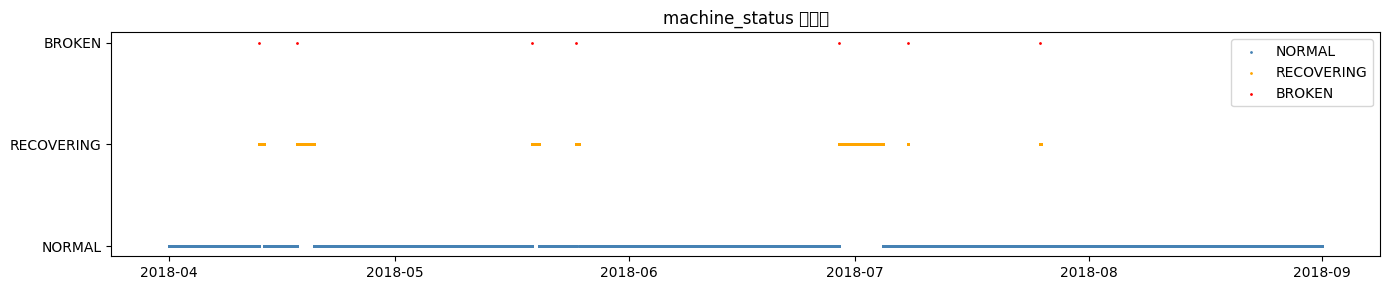

In [13]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(14, 3))

colors = {'NORMAL': 'steelblue', 'RECOVERING': 'orange', 'BROKEN': 'red'}
for status, color in colors.items():
    mask = df['machine_status'] == status
    ax.scatter(df.loc[mask, 'timestamp'], 
               [status] * mask.sum(), 
               c=color, s=1, label=status)

ax.legend()
ax.set_title('machine_status 시계열')
plt.tight_layout()
plt.show()

In [14]:
# BROKEN 직전 상태 확인
broken_idx = df[df['machine_status'] == 'BROKEN'].index
for idx in broken_idx:
    start = max(0, idx-5)
    print(df.loc[start:idx, ['timestamp', 'machine_status']])
    print('---')

                timestamp machine_status
17150 2018-04-12 21:50:00         NORMAL
17151 2018-04-12 21:51:00         NORMAL
17152 2018-04-12 21:52:00         NORMAL
17153 2018-04-12 21:53:00         NORMAL
17154 2018-04-12 21:54:00         NORMAL
17155 2018-04-12 21:55:00         BROKEN
---
                timestamp machine_status
24505 2018-04-18 00:25:00         NORMAL
24506 2018-04-18 00:26:00         NORMAL
24507 2018-04-18 00:27:00         NORMAL
24508 2018-04-18 00:28:00         NORMAL
24509 2018-04-18 00:29:00         NORMAL
24510 2018-04-18 00:30:00         BROKEN
---
                timestamp machine_status
69313 2018-05-19 03:13:00         NORMAL
69314 2018-05-19 03:14:00         NORMAL
69315 2018-05-19 03:15:00         NORMAL
69316 2018-05-19 03:16:00         NORMAL
69317 2018-05-19 03:17:00         NORMAL
69318 2018-05-19 03:18:00         BROKEN
---
                timestamp machine_status
77785 2018-05-25 00:25:00         NORMAL
77786 2018-05-25 00:26:00         NORMAL
7778

In [15]:
# BROKEN 전후 30줄 확인
for idx in broken_idx:
    start = max(0, idx-30)
    end = min(len(df), idx+5)
    subset = df.loc[start:end, ['timestamp', 'machine_status']]
    # NORMAL만 있는 줄 제외하고 출력
    print(subset[subset['machine_status'] != 'NORMAL'])
    print('---')

                timestamp machine_status
17155 2018-04-12 21:55:00         BROKEN
17156 2018-04-12 21:56:00     RECOVERING
17157 2018-04-12 21:57:00     RECOVERING
17158 2018-04-12 21:58:00     RECOVERING
17159 2018-04-12 21:59:00     RECOVERING
17160 2018-04-12 22:00:00     RECOVERING
---
                timestamp machine_status
24510 2018-04-18 00:30:00         BROKEN
24511 2018-04-18 00:31:00     RECOVERING
24512 2018-04-18 00:32:00     RECOVERING
24513 2018-04-18 00:33:00     RECOVERING
24514 2018-04-18 00:34:00     RECOVERING
24515 2018-04-18 00:35:00     RECOVERING
---
                timestamp machine_status
69318 2018-05-19 03:18:00         BROKEN
69319 2018-05-19 03:19:00     RECOVERING
69320 2018-05-19 03:20:00     RECOVERING
69321 2018-05-19 03:21:00     RECOVERING
69322 2018-05-19 03:22:00     RECOVERING
69323 2018-05-19 03:23:00     RECOVERING
---
                timestamp machine_status
77790 2018-05-25 00:30:00         BROKEN
77791 2018-05-25 00:31:00     RECOVERING
7779

In [16]:
# RECOVERING이 있는 날짜 확인
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
print(df[df['machine_status'] == 'RECOVERING']['date'].unique())

[datetime.date(2018, 4, 12) datetime.date(2018, 4, 13)
 datetime.date(2018, 4, 18) datetime.date(2018, 4, 19)
 datetime.date(2018, 4, 20) datetime.date(2018, 5, 19)
 datetime.date(2018, 5, 20) datetime.date(2018, 5, 25)
 datetime.date(2018, 6, 28) datetime.date(2018, 6, 29)
 datetime.date(2018, 6, 30) datetime.date(2018, 7, 1)
 datetime.date(2018, 7, 2) datetime.date(2018, 7, 3)
 datetime.date(2018, 7, 4) datetime.date(2018, 7, 8)
 datetime.date(2018, 7, 25)]
